In [1]:
import warnings

import numpy as np
import shap
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

warnings.simplefilter("ignore")

/Users/shreyu/VSCODE/UoN-Business-Analytics/Dissertation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_path   = "/Users/shreyu/VSCODE/UoN-Business-Analytics/Dissertation/driftDatasets/artificial/hyperplane/rotatingHyperplane.data"
labels_path = "/Users/shreyu/VSCODE/UoN-Business-Analytics/Dissertation/driftDatasets/artificial/hyperplane/rotatingHyperplane.labels"

X = np.loadtxt(data_path)            # features: a table, one row per instance
y = np.loadtxt(labels_path).astype(int)  # labels: 0 or 1, one per instance

print("Feature table shape:", X.shape)   # (rows, columns) = (instances, features)
print("Labels shape:", y.shape)

Feature table shape: (200000, 10)
Labels shape: (200000,)


In [3]:
print("First 3 rows of features:\n", X[:3])
print("\nNumber of features:", X.shape[1])
print("First 10 labels:", y[:10])
print("Class balance:", np.bincount(y))   # how many of each class

First 3 rows of features:
 [[0.397174 0.347518 0.294057 0.506484 0.115967 0.770536 0.659893 0.156747
  0.378202 0.139763]
 [0.27503  0.075388 0.610592 0.954931 0.274069 0.190202 0.001299 0.683527
  0.48626  0.487515]
 [0.233156 0.889909 0.038327 0.592379 0.655174 0.119839 0.652477 0.984323
  0.206738 0.37465 ]]

Number of features: 10
First 10 labels: [0 0 1 0 0 0 1 0 1 1]
Class balance: [100065  99935]


In [4]:
def mean_abs_shap(shap_values, n_features):
    sv = np.abs(np.array(shap_values))
    feat_axis = [ax for ax, size in enumerate(sv.shape) if size == n_features][-1]
    other_axes = tuple(ax for ax in range(sv.ndim) if ax != feat_axis)
    return sv.mean(axis=other_axes)

def shap_share(clf, Xs):
    """Normalised mean|SHAP| profile — the vector the L1 signal compares."""
    imp = mean_abs_shap(shap.TreeExplainer(clf).shap_values(Xs), Xs.shape[1])
    return imp / imp.sum()

def mean_dominance(clf, Xs):
    """Mean share of trees voting with the majority. Requires NO labels.

    The harness used frac_not_unanimous. That statistic is useless here: with
    ten continuous features almost no row is unanimous (0.99 at baseline), so
    it saturates at 1.0. The mean still moves, so use the mean on this stream."""
    Xa = np.asarray(Xs, dtype=np.float32)
    p1 = np.stack([clf.classes_[t.predict(Xa).astype(int)]
                   for t in clf.estimators_]).mean(axis=0)
    return float(np.maximum(p1, 1.0 - p1).mean())


In [5]:
def windowed_importance(X, y, window=1000, sample=200, seed=0):
    rng = np.random.default_rng(seed)
    n, d = X.shape

    retrained_imp, frozen_imp, frozen_acc, dominance, centers = [], [], [], [], []
    fixed_model = None

    for w in range(n // window):
        lo, hi = w * window, (w + 1) * window
        Xw, yw = X[lo:hi], y[lo:hi]
        if len(np.unique(yw)) < 2:
            continue

        idx = rng.choice(len(Xw), min(sample, len(Xw)), replace=False)
        clf = RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                     random_state=seed).fit(Xw, yw)
        retrained_imp.append(shap_share(clf, Xw[idx]))
        centers.append((lo + hi) // 2)

        if fixed_model is None:
            fixed_model = clf                       # deploy window 0, then freeze
            frozen_imp.append(retrained_imp[-1]); frozen_acc.append(np.nan)
        else:
            frozen_imp.append(shap_share(fixed_model, Xw[idx]))
            frozen_acc.append(fixed_model.score(Xw, yw))

        dominance.append(mean_dominance(fixed_model, Xw))

    return (np.array(retrained_imp), np.array(frozen_imp), np.array(frozen_acc),
            np.array(dominance), np.array(centers), fixed_model)


(retrained_imp, frozen_imp, fixed_acc,
 dominance, centers, fixed_model) = windowed_importance(X, y, window=1000)
print("Computed signals for", len(centers), "windows.")


Computed signals for 200 windows.


In [6]:
plt.rcParams.update({
    "figure.dpi": 200, "savefig.dpi": 200,
    "font.family": "serif", "font.size": 9,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
})
CB  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]
win = np.arange(len(centers))
d   = X.shape[1]

def save(fig, name):
    fig.tight_layout(); fig.savefig(name, bbox_inches="tight"); print("wrote", name)


wrote fig3_1_swing.png
refitted [0.207 0.109 0.192 0.086 0.417 0.201 0.239 0.148 0.288 0.26 ]
frozen   [0.023 0.013 0.006 0.012 0.026 0.009 0.03  0.029 0.029 0.035]


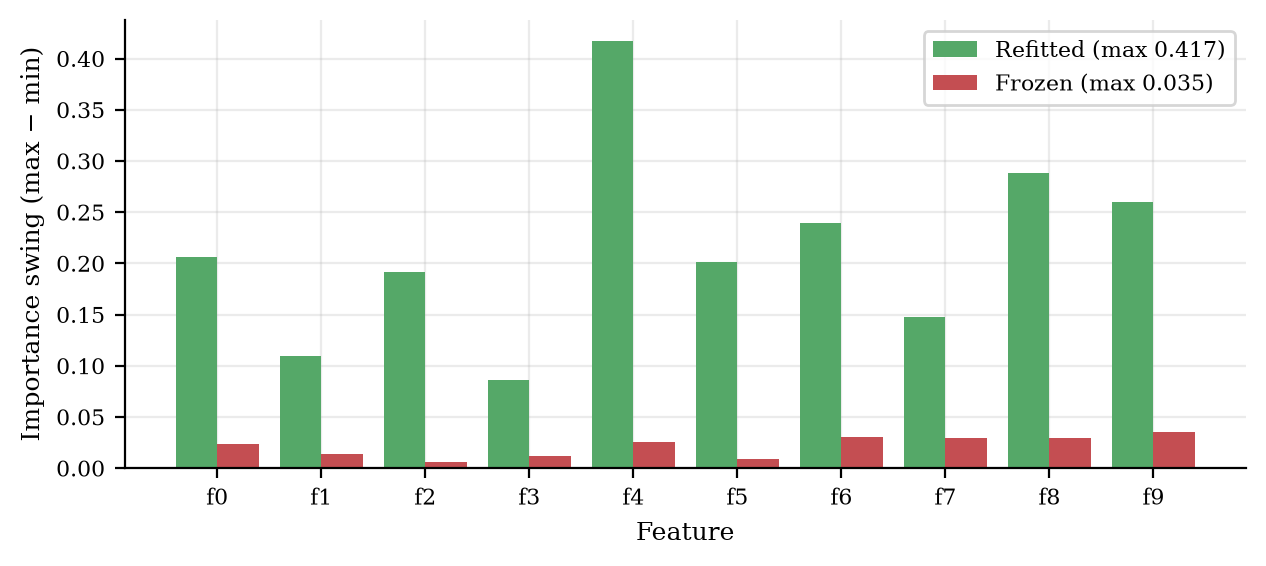

In [7]:
sw_r = retrained_imp.max(0) - retrained_imp.min(0)
sw_f = frozen_imp.max(0)    - frozen_imp.min(0)

fig, ax = plt.subplots(figsize=(6.4, 2.9))
b = np.arange(d)
ax.bar(b - 0.2, sw_r, 0.4, color=CB[2], label=f"Refitted (max {sw_r.max():.3f})")
ax.bar(b + 0.2, sw_f, 0.4, color=CB[3], label=f"Frozen (max {sw_f.max():.3f})")
ax.set_xticks(b); ax.set_xticklabels([f"f{i}" for i in range(d)])
ax.set_xlabel("Feature"); ax.set_ylabel("Importance swing (max − min)")
ax.legend(); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
save(fig, "fig3_1_swing.png")
print("refitted", np.round(sw_r, 3)); print("frozen  ", np.round(sw_f, 3))


wrote fig3_4_trajectories.png


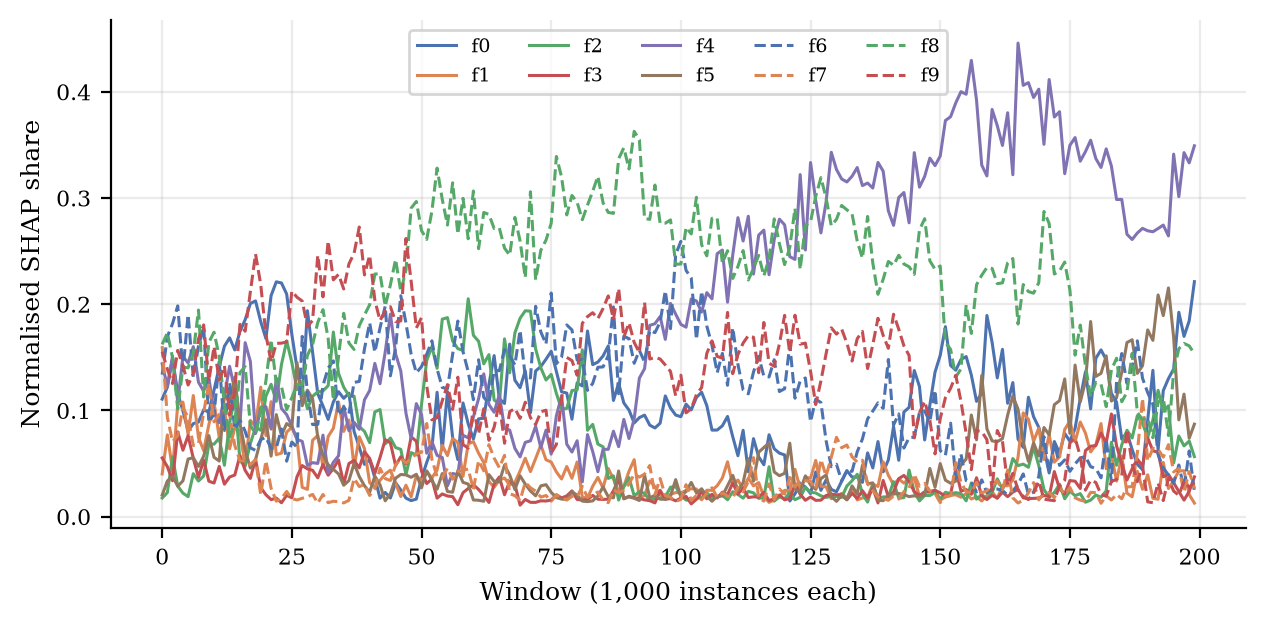

In [8]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
for i in range(d):
    ax.plot(win, retrained_imp[:, i], lw=1.1, color=CB[i % 6],
            ls=["-", "--", ":"][i // 6 % 3], label=f"f{i}")
ax.set_xlabel("Window (1,000 instances each)"); ax.set_ylabel("Normalised SHAP share")
ax.legend(ncol=5, fontsize=7, loc="upper center")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
save(fig, "fig3_4_trajectories.png")


In [9]:
SEEDS, W, SAMPLE = range(8), 1000, 200
X0, y0 = X[:W], y[:W]

# Bootstrap window 0, don't just vary the forest seed. Between two real windows
# BOTH the sample and the fit differ, so a seed-only band underestimates the
# noise (0.026 vs 0.133 here) and every signal alarms at window 1.
boot_shap, boot_dom = [], []
for s in SEEDS:
    r  = np.random.default_rng(100 + s)
    bi = r.choice(W, W, replace=True)
    Xb, yb = X0[bi], y0[bi]
    c = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=s).fit(Xb, yb)
    boot_shap.append(shap_share(c, Xb[r.choice(W, SAMPLE, replace=False)]))
    boot_dom.append(mean_dominance(c, Xb))
boot_shap = np.array(boot_shap)

shp_ref  = boot_shap.mean(0)
null_shp = np.abs(boot_shap - shp_ref).sum(1).max()
dom_ref  = float(np.mean(boot_dom))
null_dom = float(np.max(np.abs(np.array(boot_dom) - dom_ref)))

retr_L1 = np.abs(retrained_imp - shp_ref).sum(1)
froz_L1 = np.abs(frozen_imp    - shp_ref).sum(1)
dom_dev = np.abs(dominance - dom_ref)

def first_alarm(sig, thr, persist=3, start=1):
    """start=1 skips window 0, which is the model's own training window."""
    for i in range(start, len(sig) - persist + 1):
        if (sig[i:i + persist] > thr).all():
            return i
    return None

ref_acc = np.nanmean(fixed_acc[1:21])
t_deg   = first_alarm(ref_acc - fixed_acc, 0.02)

print(f"null band   SHAP L1 {null_shp:.4f} | mean dominance {null_dom:.4f}")
print(f"baseline accuracy {ref_acc:.3f} | degradation at window {t_deg}\n")
print(f"{'signal':<24}{'labels?':<10}{'alarm':<8}lead time")
ALARMS = {}
for nm, sig, thr, lab in [("Refitted SHAP L1",    retr_L1, null_shp, "yes"),
                          ("Frozen SHAP L1",      froz_L1, null_shp, "no"),
                          ("Mean vote dominance", dom_dev, null_dom, "no")]:
    a = first_alarm(sig, thr); ALARMS[nm] = a
    lead = "-" if (a is None or t_deg is None) else t_deg - a
    print(f"{nm:<24}{lab:<10}{str(a):<8}{lead}")


null band   SHAP L1 0.1327 | mean dominance 0.0039
baseline accuracy 0.793 | degradation at window 18

signal                  labels?   alarm   lead time
Refitted SHAP L1        yes       1       17
Frozen SHAP L1          no        None    -
Mean vote dominance     no        1       17


wrote fig3_7_signals.png


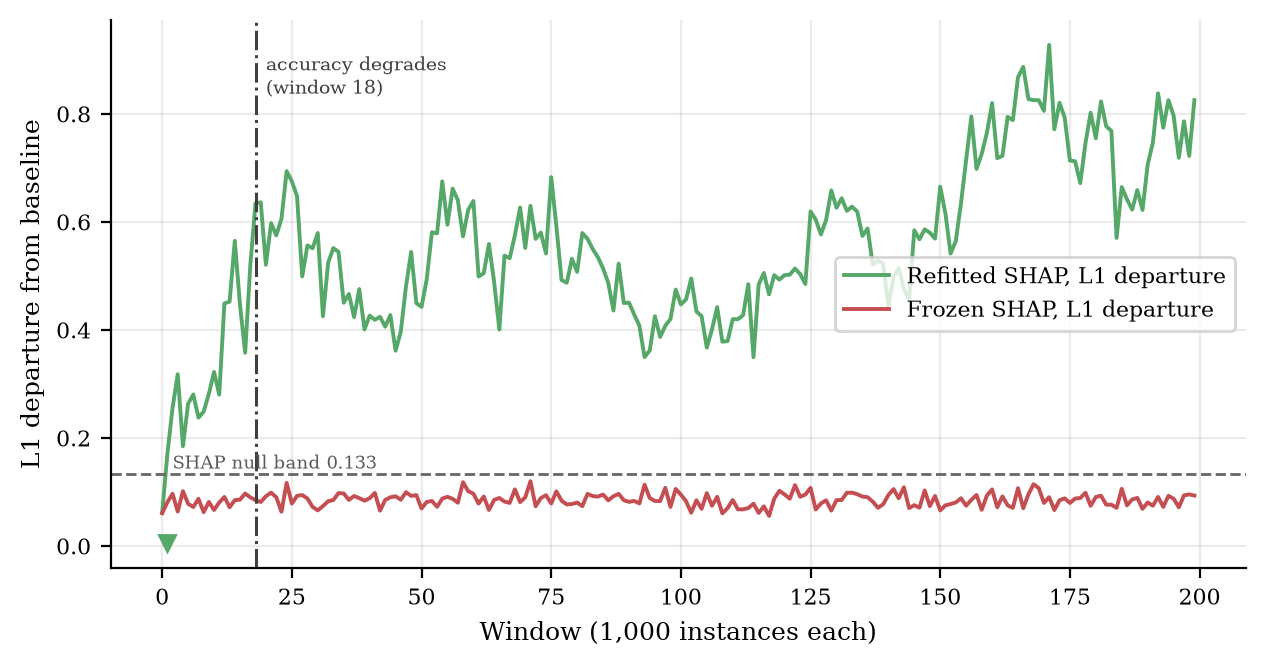

In [10]:
fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot(win, retr_L1, color=CB[2], lw=1.4, label="Refitted SHAP, L1 departure")
ax.plot(win, froz_L1, color=CB[3], lw=1.4, label="Frozen SHAP, L1 departure")
ax.axhline(null_shp, color="0.4", ls="--", lw=1)
ax.text(2, null_shp * 1.08, f"SHAP null band {null_shp:.3f}", fontsize=6.5, color="0.35")

for nm, sig, c in [("Refitted SHAP L1", retr_L1, CB[2]), ("Frozen SHAP L1", froz_L1, CB[3])]:
    a = ALARMS[nm]
    if a is not None:
        ax.plot(a, 0.005, marker="v", color=c, ms=6, clip_on=False)

if t_deg is not None:
    ax.axvline(t_deg, color="0.25", ls="-.", lw=1.1)
    ax.text(t_deg + 2, ax.get_ylim()[1] * 0.86,
            f"accuracy degrades\n(window {t_deg})", fontsize=7, color="0.25")

ax.set_xlabel("Window (1,000 instances each)"); ax.set_ylabel("L1 departure from baseline")
ax.legend(loc="center right")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
save(fig, "fig3_7_signals.png")


In [11]:
# RQ3 baseline arm on the primary stream.
# DDM and ADWIN monitor a DEPLOYED model's error stream, so the frozen
# forest fitted on window 0 is the correct source.
#
# Window 0 is that model's own training window and is excluded, which
# matches start=1 in the signal-side first_alarm above.

from river.drift import ADWIN
from river.drift.binary import DDM


# Pylance/runtime guard: the frozen window-0 model must already exist.
if fixed_model is None:
    raise RuntimeError(
        "fixed_model has not been fitted. Run the upstream window-0 "
        "model-fitting cell before this RQ3 baseline cell."
    )


# Binary error stream in chronological instance order:
# 0 = correct prediction, 1 = prediction error.
err = (fixed_model.predict(X[W:]) != y[W:]).astype(int)

print(
    f"frozen error stream: {err.sum():,} / {len(err):,} "
    f"({err.mean():.3f} error rate)\n"
)


def detector_alarms(errors, detector, offset=W, window=W):
    """Every alarm the detector raises, reported in window indices."""
    out = []

    for i, e in enumerate(errors):
        detector.update(int(e))

        if detector.drift_detected:
            out.append((offset + i) // window)

    return out


DET = {}

for dname, det in [
    ("ADWIN", ADWIN()),
    ("DDM", DDM()),
]:
    alarms = detector_alarms(err, det)

    DET[dname] = alarms[0] if alarms else None

    print(
        f"{dname:<6} first alarm: "
        f"{'never' if not alarms else f'window {alarms[0]}':<12}"
        f"total alarms: {len(alarms)}"
    )


print(f"\n{'signal':<26}{'labels?':<10}alarm window")

for name, labels in [
    ("Refitted SHAP L1", "yes"),
    ("Frozen SHAP L1", "no"),
    ("Mean vote dominance", "no"),
]:
    print(f"{name:<26}{labels:<10}{ALARMS[name]}")


for dname in ("ADWIN", "DDM"):
    print(
        f"{dname + ' (frozen errors)':<26}"
        f"{'yes':<10}"
        f"{DET[dname]}"
    )


# Lead time is deliberately not computed here.
# t_deg from the previous cell uses a reference period that contains the
# degradation point; both numbers are recomputed once that baseline is fixed.

frozen error stream: 51,557 / 199,000 (0.259 error rate)

ADWIN  first alarm: window 14   total alarms: 8
DDM    first alarm: window 1    total alarms: 2

signal                    labels?   alarm window
Refitted SHAP L1          yes       1
Frozen SHAP L1            no        None
Mean vote dominance       no        1
ADWIN (frozen errors)     yes       14
DDM (frozen errors)       yes       1


In [12]:
# Is the DDM window-1 alarm informative, or an artefact of its own
# initialisation? Permuting the error stream preserves the error rate exactly
# and destroys all temporal structure, so an alarm that survives permutation
# is a property of the detector rather than evidence of drift.

def alarm_instances(errors, detector, offset=W):
    """Absolute instance index of every alarm."""
    out = []
    for i, e in enumerate(errors):
        detector.update(int(e))
        if detector.drift_detected:
            out.append(offset + i)
    return out

print("frozen accuracy, windows 1-6:", np.round(fixed_acc[1:7], 3))
print(f"stream error rate: {err.mean():.3f}\n")

print(f"{'stream':<16}{'detector':<8}{'first alarm':<28}total")
for sname, e in [("chronological", err)] + \
                [(f"permuted s{s}", np.random.default_rng(s).permutation(err))
                 for s in range(3)]:
    for dname, det in [("ADWIN", ADWIN()), ("DDM", DDM())]:
        a = alarm_instances(e, det)
        first = "never" if not a else f"instance {a[0]:,} (window {a[0] // W})"
        print(f"{sname:<16}{dname:<8}{first:<28}{len(a)}")

frozen accuracy, windows 1-6: [0.806 0.83  0.819 0.814 0.826 0.813]
stream error rate: 0.259

stream          detectorfirst alarm                 total
chronological   ADWIN   instance 14,407 (window 14) 8
chronological   DDM     instance 1,748 (window 1)   2
permuted s0     ADWIN   never                       0
permuted s0     DDM     instance 2,173 (window 2)   2
permuted s1     ADWIN   never                       0
permuted s1     DDM     instance 1,157 (window 1)   1
permuted s2     ADWIN   never                       0
permuted s2     DDM     never                       0


In [13]:
# The dominance reference in cell 9 is measured in-sample, on the rows the
# bootstrap forest trained on, while the signal is measured on unseen windows.
# A forest is more unanimous on its own training data, so the reference carries
# an optimism offset unrelated to drift. Calibrate frozen-model signals OOB.

def calibrate(Xs, ys):
    """Match each reference to how its later signal is measured."""
    X0s, y0s = Xs[:W], ys[:W]
    ins, frz, dom = [], [], []
    for s in SEEDS:
        r = np.random.default_rng(100 + s)
        bi = r.choice(W, W, replace=True)
        oob = np.setdiff1d(np.arange(W), bi)
        if len(np.unique(y0s[bi])) < 2:
            raise RuntimeError(f"bootstrap seed {s} produced a one-class fit")
        if len(oob) < SAMPLE:
            raise RuntimeError(f"bootstrap seed {s} produced only {len(oob)} OOB rows")
        c = RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                   random_state=s).fit(X0s[bi], y0s[bi])
        ins.append(shap_share(c, X0s[bi][r.choice(W, SAMPLE, replace=False)]))
        frz.append(shap_share(c, X0s[r.choice(oob, SAMPLE, replace=False)]))
        dom.append(mean_dominance(c, X0s[oob]))
    ins, frz, dom = np.array(ins), np.array(frz), np.array(dom)
    if not (np.isfinite(ins).all() and np.isfinite(frz).all() and np.isfinite(dom).all()):
        raise RuntimeError("calibration produced a non-finite value")
    return {"ins_ref": ins.mean(0),
            "ins_band": float(np.abs(ins - ins.mean(0)).sum(1).max()),
            "frz_ref": frz.mean(0),
            "frz_band": float(np.abs(frz - frz.mean(0)).sum(1).max()),
            "dom_ref": float(dom.mean()),
            "dom_band": float(np.abs(dom - dom.mean()).max())}

def alarms(cal, sig):
    r_imp, f_imp, dm = sig
    return {"Refitted SHAP L1": first_alarm(
                np.abs(r_imp - cal["ins_ref"]).sum(1), cal["ins_band"]),
            "Frozen SHAP L1": first_alarm(
                np.abs(f_imp - cal["frz_ref"]).sum(1), cal["frz_band"]),
            "Mean vote dominance": first_alarm(
                np.abs(dm - cal["dom_ref"]), cal["dom_band"])}

pi = np.random.default_rng(0).permutation(len(X))
cal_c, cal_p = calibrate(X, y), calibrate(X[pi], y[pi])
perm = windowed_importance(X[pi], y[pi], window=W, sample=SAMPLE)
expected_windows = len(X) // W
if len(retrained_imp) != expected_windows or len(perm[0]) != expected_windows:
    raise RuntimeError("a one-class window was skipped; alarm indices are misaligned")
if not (np.allclose(cal_c["ins_ref"], shp_ref) and
        np.isclose(cal_c["ins_band"], null_shp)):
    raise RuntimeError("refitted-SHAP calibration no longer reproduces cell 9")
A_c = alarms(cal_c, (retrained_imp, frozen_imp, dominance))
A_p = alarms(cal_p, (perm[0], perm[1], perm[3]))

old_dom_dev = np.abs(dominance[1:4] - dom_ref)
oob_dom_dev = np.abs(dominance[1:4] - cal_c["dom_ref"])
print(f"dominance reference   in-sample {dom_ref:.4f}  band {null_dom:.4f}")
print(f"                      out-of-bag {cal_c['dom_ref']:.4f}  band {cal_c['dom_band']:.4f}")
print(f"frozen SHAP band      in-sample {null_shp:.4f} -> out-of-bag {cal_c['frz_band']:.4f}\n")
print("dominance deviations, chronological windows 1-3")
print(f"  from in-sample ref {np.round(old_dom_dev, 4)}  band {null_dom:.4f}")
print(f"  from OOB ref       {np.round(oob_dom_dev, 4)}  band {cal_c['dom_band']:.4f}\n")
print(f"mean frozen accuracy  chronological {np.nanmean(fixed_acc):.3f}  permuted {np.nanmean(perm[2]):.3f}\n")

print(f"{'signal':<24}{'chronological':<16}permuted")
for nm in ("Refitted SHAP L1", "Frozen SHAP L1", "Mean vote dominance"):
    print(f"{nm:<24}{str(A_c[nm]):<16}{A_p[nm]}")

dominance reference   in-sample 0.9358  band 0.0039
                      out-of-bag 0.7238  band 0.0165
frozen SHAP band      in-sample 0.1327 -> out-of-bag 0.1440

dominance deviations, chronological windows 1-3
  from in-sample ref [0.2144 0.208  0.2079]  band 0.0039
  from OOB ref       [0.0023 0.004  0.0041]  band 0.0165

mean frozen accuracy  chronological 0.741  permuted 0.781

signal                  chronological   permuted
Refitted SHAP L1        1               5
Frozen SHAP L1          None            None
Mean vote dominance     None            None
